Denna notebook undersöker återhämtning efter en extrem förlust som definieras enligt POT. 

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp 
import importlib
import EVTLibrary as evt
importlib.reload(evt)
from scipy.stats import kstest
import matplotlib.patches as mpatches

In [16]:
u_prel = [0.041, 0.035, 0.042, 0.035, 0.045, 0.044, 0.046, 0.045, 0.040, 0.037]
loss_df = evt.get_data(start="2000-01-01", end="2026-03-31")
u, extreme_values = evt.get_extreme_data(u_prel, loss_df, False)

# Återhämtningsdel

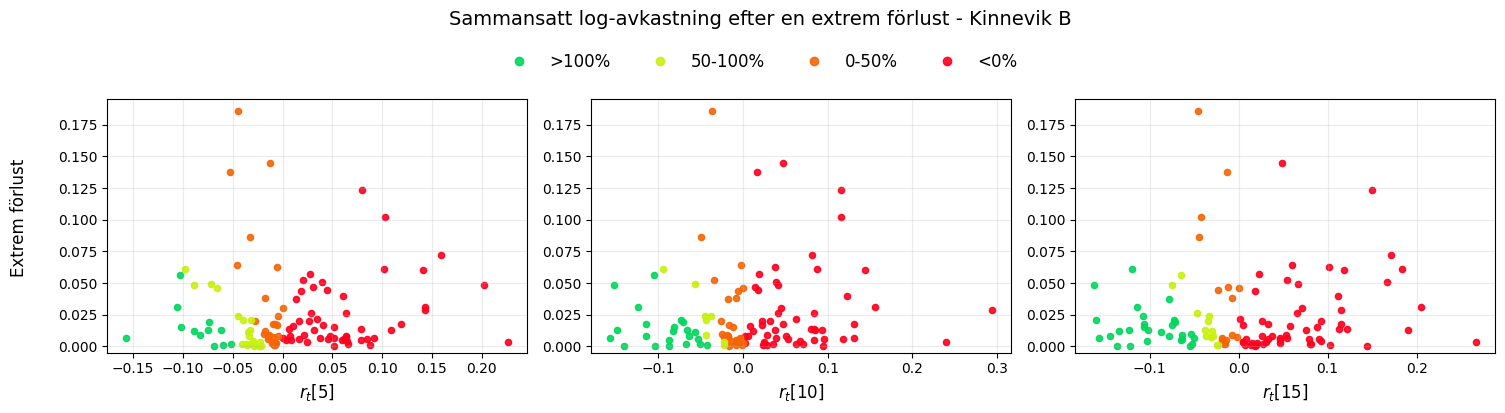

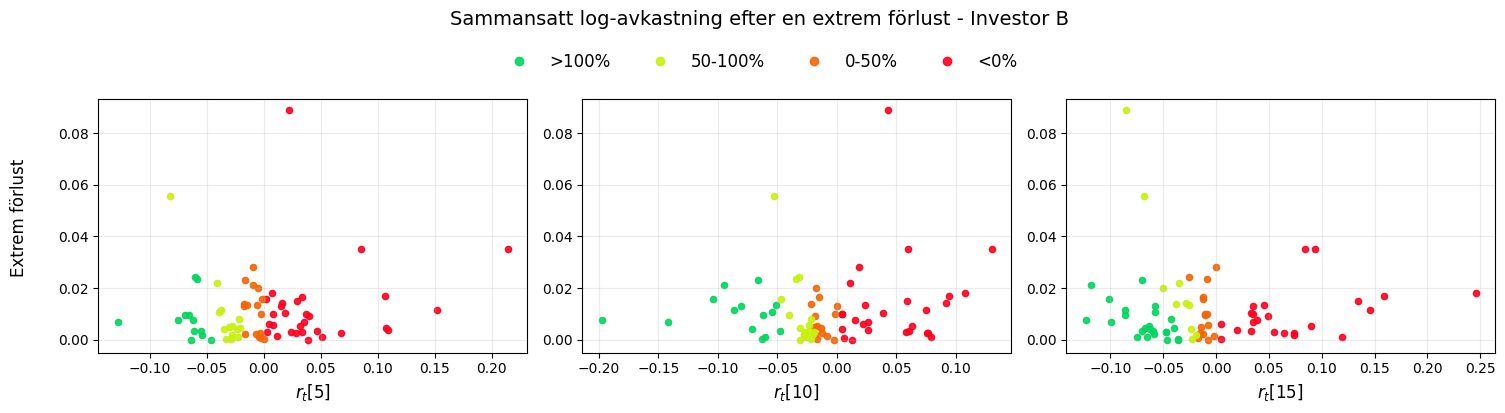

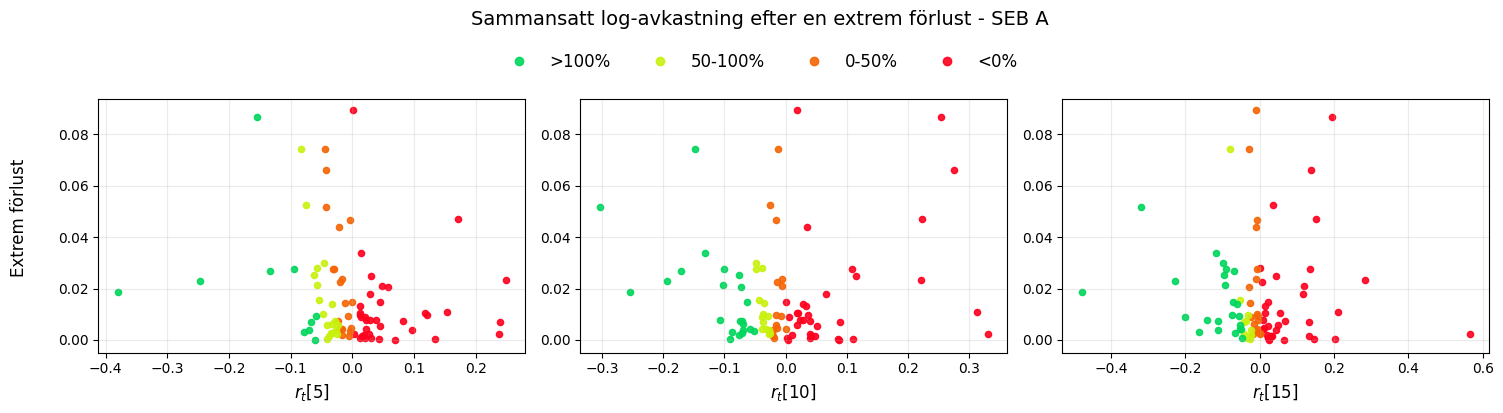

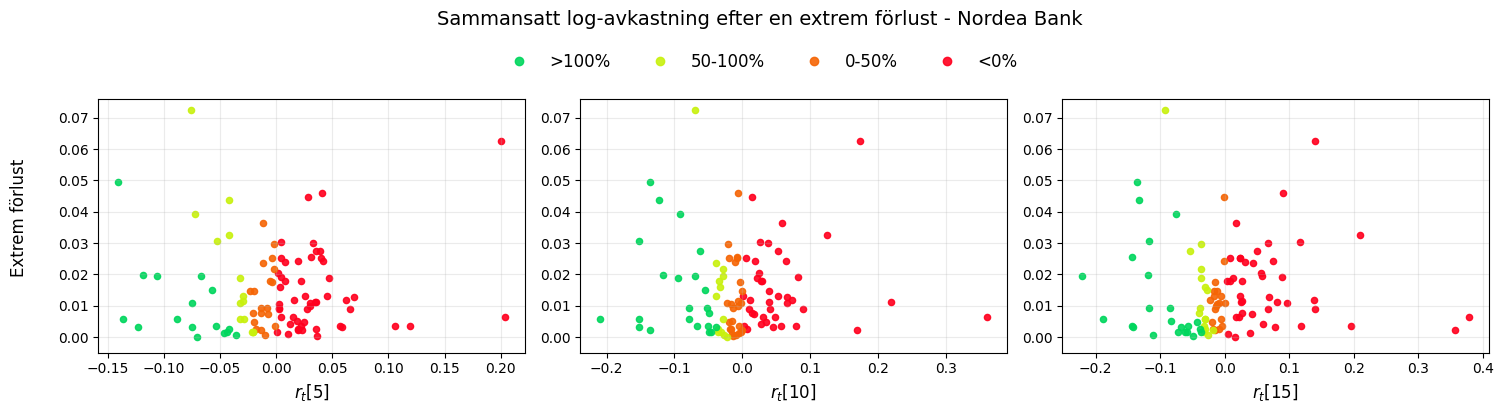

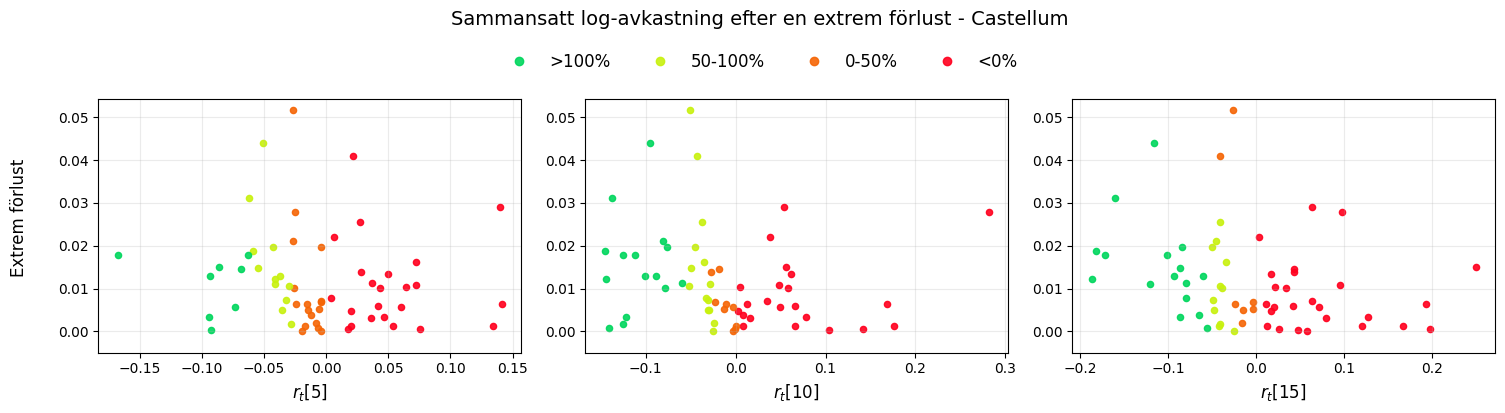

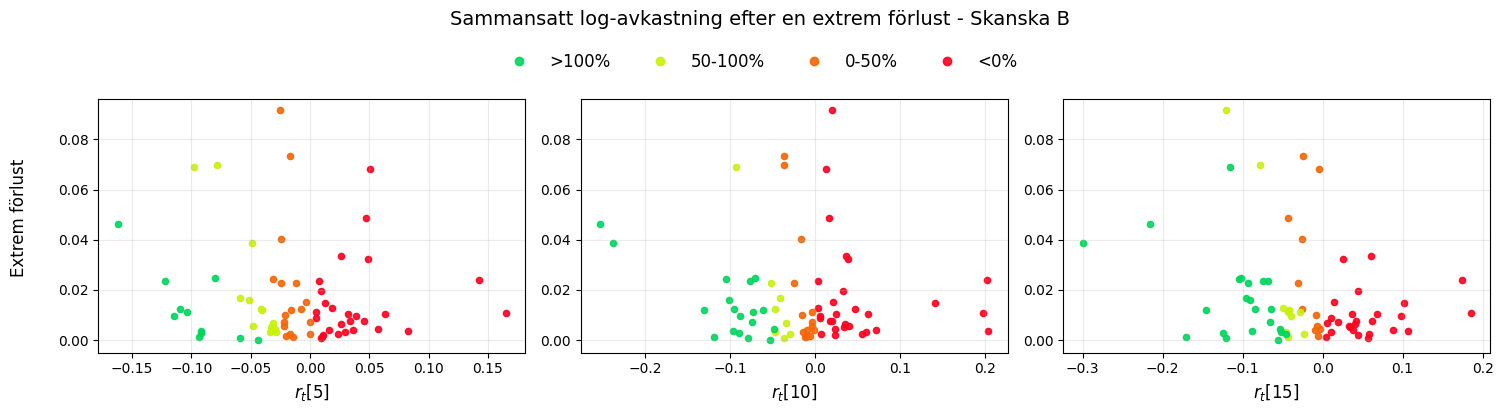

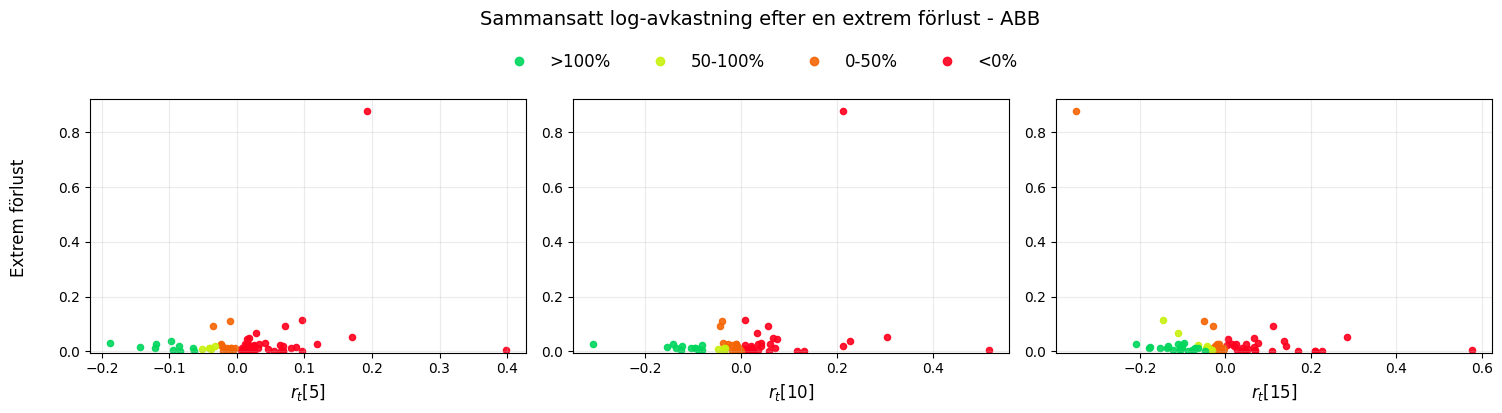

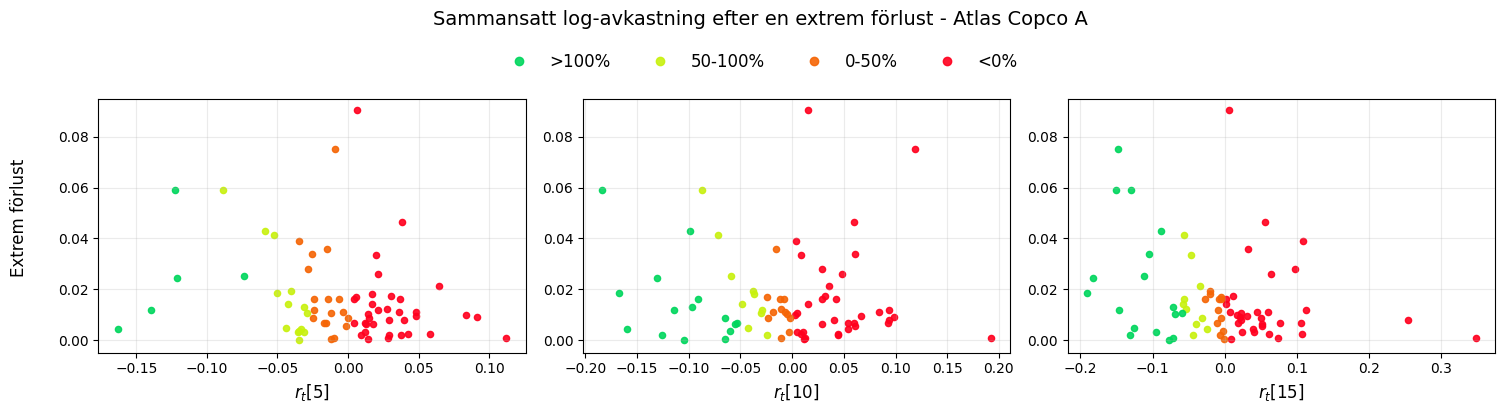

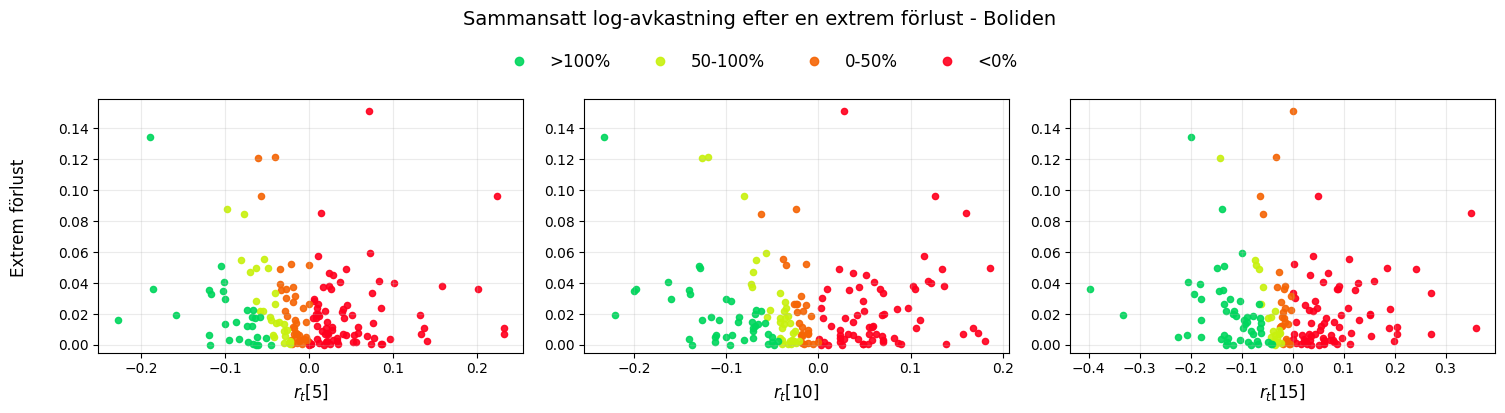

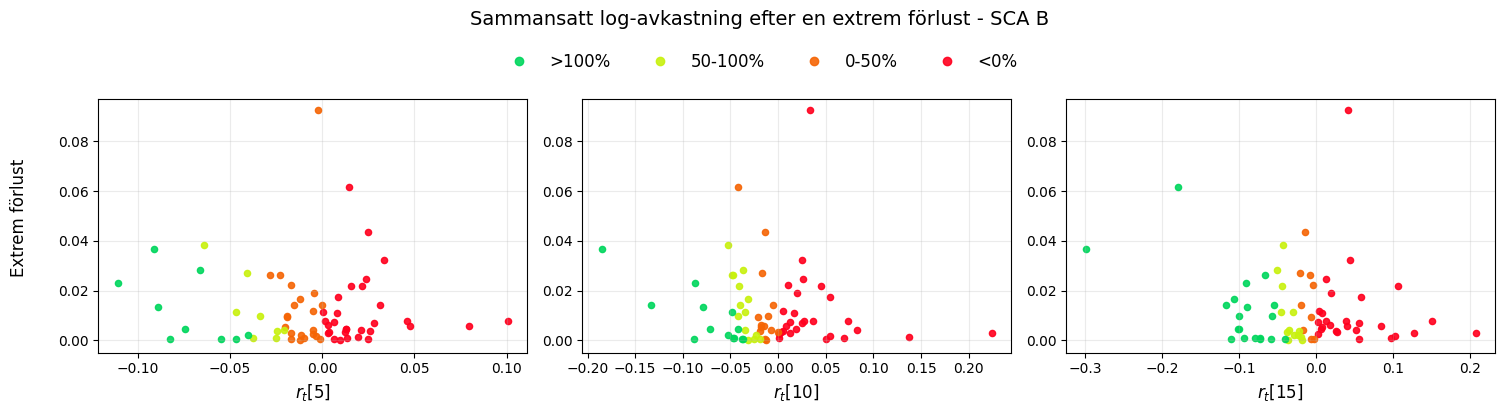

In [17]:
observation_window = 15          
recovery_horizons = [5, 10, 15]  

for stock in loss_df.columns:
    recovery_windows = evt.staticFiltering(u, loss_df, observation_window)

    ncols = min(3, len(recovery_horizons))
    nrows = int(np.ceil(len(recovery_horizons) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, s in enumerate(recovery_horizons):
        ax = axes[i]
        ratios, recoveries, no_recovery, recovery_50minus, recovery_50plus, full_recovery = evt.Generate_Recovery_Data(loss_df, recovery_windows,stock,window_size=s)
        col = f"{s} day recovery"

        ax.scatter(no_recovery[col], no_recovery["Loss"] - u[stock], s=20, alpha=0.9,color="#ff001e") 
        ax.scatter(recovery_50minus[col],recovery_50minus["Loss"] - u[stock],s=20, alpha=0.9,color="#f56505")  
        ax.scatter(recovery_50plus[col], recovery_50plus["Loss"] - u[stock],s=20, alpha=0.9,color="#c8f10e")   
        ax.scatter(full_recovery[col],full_recovery["Loss"] - u[stock],s=20, alpha=0.9,color="#00d65d")   

        ax.set_xlabel(rf"$r_t[{s}]$", fontsize=12)
        ax.grid(True, alpha=0.25)
        ax.set_ylim(bottom=-0.005)
        

    for j in range(len(recovery_horizons), len(axes)):
        fig.delaxes(axes[j])

    handles = [
        plt.Line2D([], [], marker='o', linestyle='', alpha=0.9,color="#00d65d", label='>100%'),
        plt.Line2D([], [], marker='o', linestyle='', alpha=0.9,color="#c8f10e", label='50-100%'),
        plt.Line2D([], [], marker='o', linestyle='', alpha=0.9,color="#f56505", label='0-50%'),
        plt.Line2D([], [], marker='o', linestyle='', alpha=0.9,color="#ff001e", label='<0%')
    ]

    fig.legend(handles=handles, loc='upper center',bbox_to_anchor=(0.5, 0.95), ncol=4,frameon=False, fontsize=12)
    fig.supylabel("Extrem förlust", fontsize=12, x=0)
    fig.suptitle(f"Sammansatt log-avkastning efter en extrem förlust - {stock}", y=1.02,fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

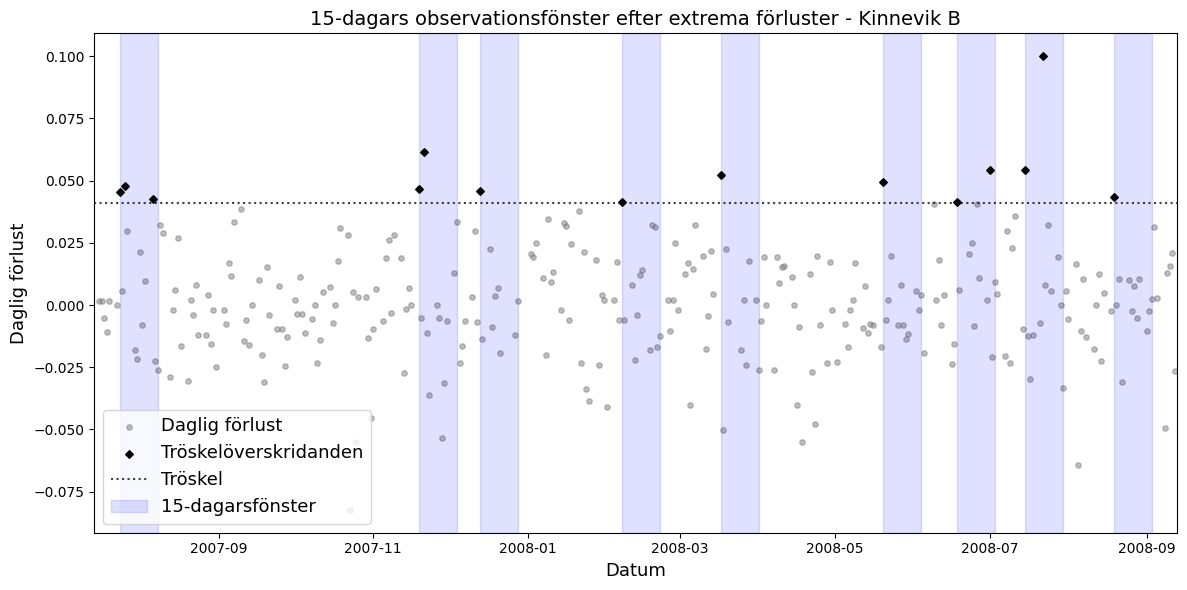

2007-07-14 00:00:00
2008-09-13 00:00:00


In [18]:
stock = "Kinnevik B"
static_window_size = 15

recovery_windows = evt.staticFiltering(u, loss_df, static_window_size)

rw = recovery_windows[stock]

# Välj några statiska fönster
subset_windows = rw.iloc[25:34]

start = subset_windows["start"].min() - pd.Timedelta(days=10)
end = subset_windows["end"].max() + pd.Timedelta(days=10)

loss_window = loss_df[stock].loc[start:end]

plt.figure(figsize=(12, 6))

# Alla observationer i perioden
plt.scatter(loss_window.index,loss_window.values,color="grey",alpha=0.5,s=15,label="Daglig förlust")

# Extrema förluster inom perioden
extreme_mask = loss_window > u[stock]
extreme_window = loss_window[extreme_mask]

plt.scatter(extreme_window.index,extreme_window.values,marker = "D", color="black",s=15,zorder=3,label="Tröskelöverskridanden")

# Startpunkter för statiska fönster
window_starts = subset_windows["start"]
window_start_losses = loss_df.loc[window_starts, stock]

# Tröskel
plt.axhline(u[stock],color="black",alpha=0.75,linestyle=":",label="Tröskel")

# Skuggade statiska observationsfönster
for i, row in subset_windows.iterrows():
    label = "15-dagarsfönster" if i == subset_windows.index[0] else None
    plt.axvspan(row["start"],row["end"],alpha=0.12,color="blue",label=label)

plt.xlim(start, end)
plt.title(f"15-dagars observationsfönster efter extrema förluster - {stock}",fontsize=14)
plt.xlabel("Datum", fontsize=13)
plt.ylabel("Daglig förlust", fontsize=13)
plt.grid(False)
plt.legend(fontsize=13, loc="lower left")
plt.tight_layout()
plt.show()

print(start)
print(end)

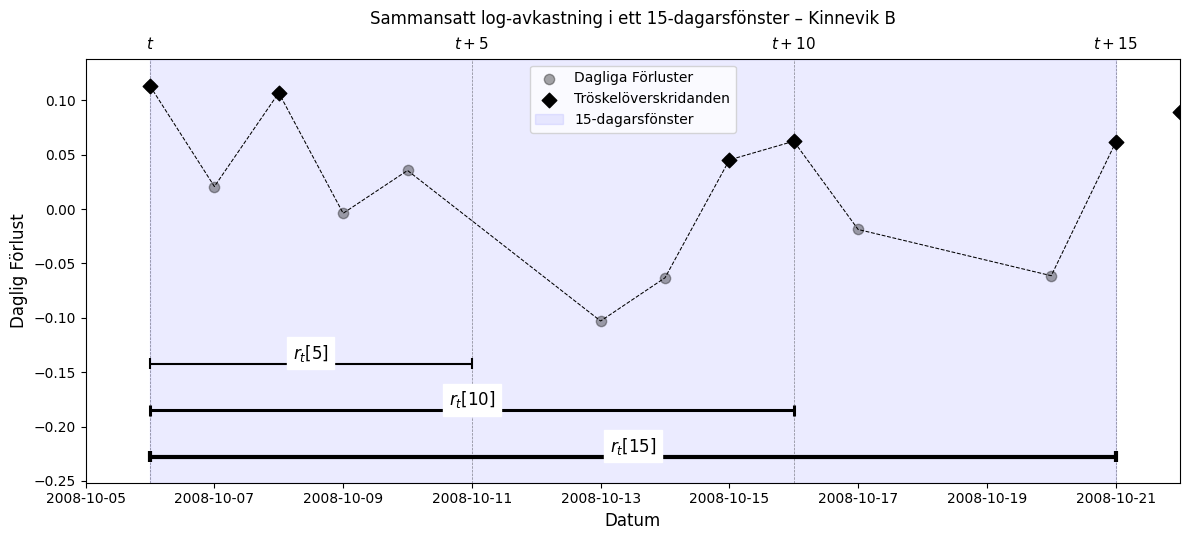

In [19]:
stock = "Kinnevik B"
static_window_size = 15
window_id = 35

recovery_windows = evt.staticFiltering(u, loss_df, static_window_size)
rw = recovery_windows[stock]

row = rw.iloc[window_id]
t0 = row["start"]
t15 = row["end"]

start = t0 - pd.Timedelta(days=1)
end = t15 + pd.Timedelta(days=1)

x = loss_df[stock].loc[start:end]
x_window = loss_df[stock].loc[t0:t15]

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.scatter(x.index,x.values, color="black", alpha=0.35, s=55, zorder=3, label="Dagliga Förluster")

# Observationer inom det statiska fönstret
ax.plot(x_window.index, x_window.values, color="black",linestyle = "--", linewidth = 0.75)


extreme_points = x[x > u[stock]]
ax.scatter(extreme_points.index, extreme_points.values,color="black",marker = "D", s=55,zorder=4,label="Tröskelöverskridanden")
#ax.axhline(u[stock],color="black",linestyle=":",linewidth=1.2,label="Tröskel")
ax.axvspan(t0, t15, color="blue",alpha=0.08,label="15-dagarsfönster")

# Vertikala cutoff-linjer
for s in [0, 5, 10, 15]:
    ax.axvline(t0 + pd.Timedelta(days=s),color="black",linestyle="--",linewidth=0.5,alpha=0.45,zorder=2)

# Etiketter ovanför själva grafområdet, men under titeln
for s in [0, 5, 10, 15]:
    label = r"$t$" if s == 0 else rf"$t+{s}$"
    ax.text(t0 + pd.Timedelta(days=s),1.015,label,transform=ax.get_xaxis_transform(),ha="center",va="bottom",fontsize=11,clip_on=False)

ymin, ymax = ax.get_ylim()
yrange = ymax - ymin

new_ymin = ymin - 0.58 * yrange
ax.set_ylim(new_ymin, ymax + 0.06 * yrange)

levels = [
    (5,  new_ymin + 0.46 * yrange, r"$r_t[5]$"),
    (10, new_ymin + 0.28 * yrange, r"$r_t[10]$"),
    (15, new_ymin + 0.10 * yrange, r"$r_t[15]$")
]

widths = {5: 1.5, 10: 2.2, 15: 3.0}

for s, y, label in levels:
    x_start = t0
    x_end = t0 + pd.Timedelta(days=s)

    ax.hlines(y,x_start,x_end,linewidth=widths[s],color="black")
    ax.vlines([x_start, x_end],y - 0.005, y + 0.005,linewidth=widths[s],color="black")
    ax.text(t0 + pd.Timedelta(days=s / 2), y, label,ha="center",va="bottom",fontsize=12,backgroundcolor="white")


ymin, ymax = ax.get_ylim()
yrange = ymax - ymin

levels = [
    (5,  new_ymin + 0.46 * yrange, r"$r_t[5]$"),
    (10, new_ymin + 0.28 * yrange, r"$r_t[10]$"),
    (15, new_ymin + 0.10 * yrange, r"$r_t[15]$")
]

ax.set_xlim(start, end)
ax.set_title(rf"Sammansatt log-avkastning i ett {static_window_size}-dagarsfönster – {stock}",pad=25)

ax.set_xlabel("Datum", fontsize=12)
ax.set_ylabel("Daglig Förlust", fontsize=12)

ax.legend()
plt.tight_layout()
plt.show()

# Distributionsdel

### Visualisering av hur väl anpassade återhämtningarna är för normalfördelningen

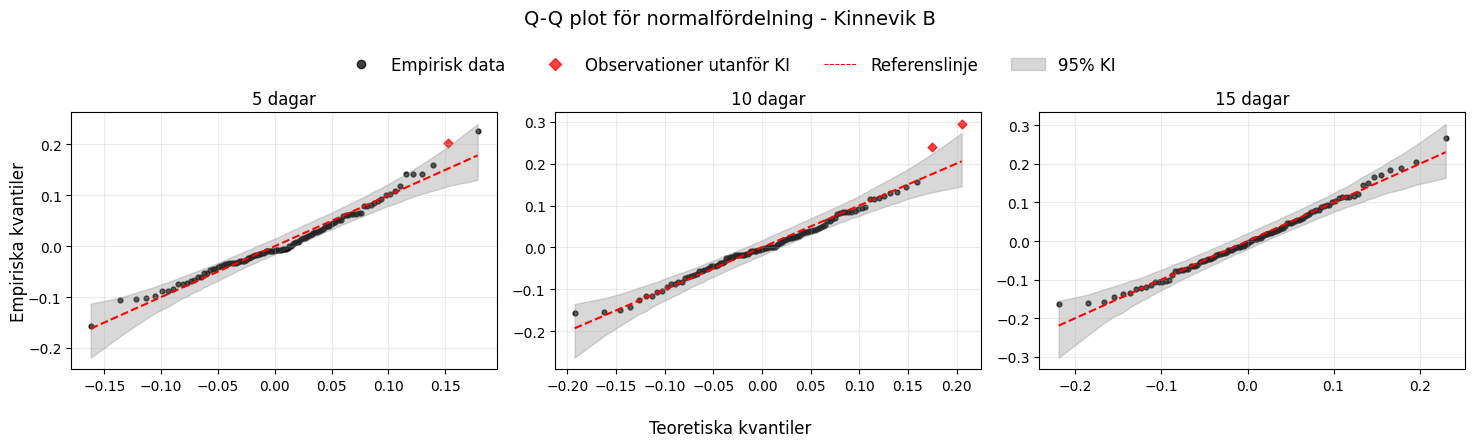

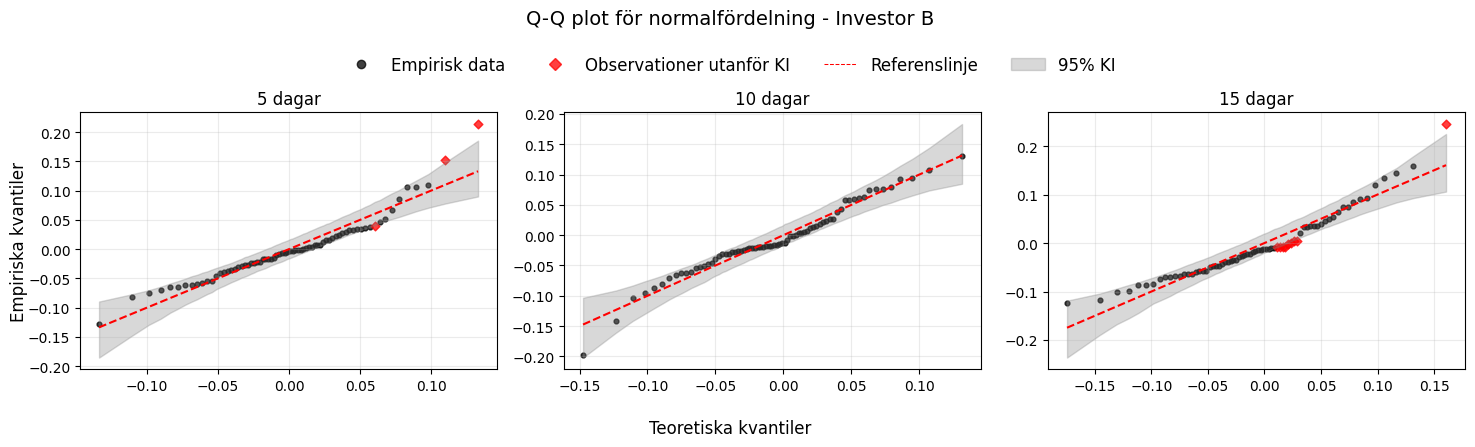

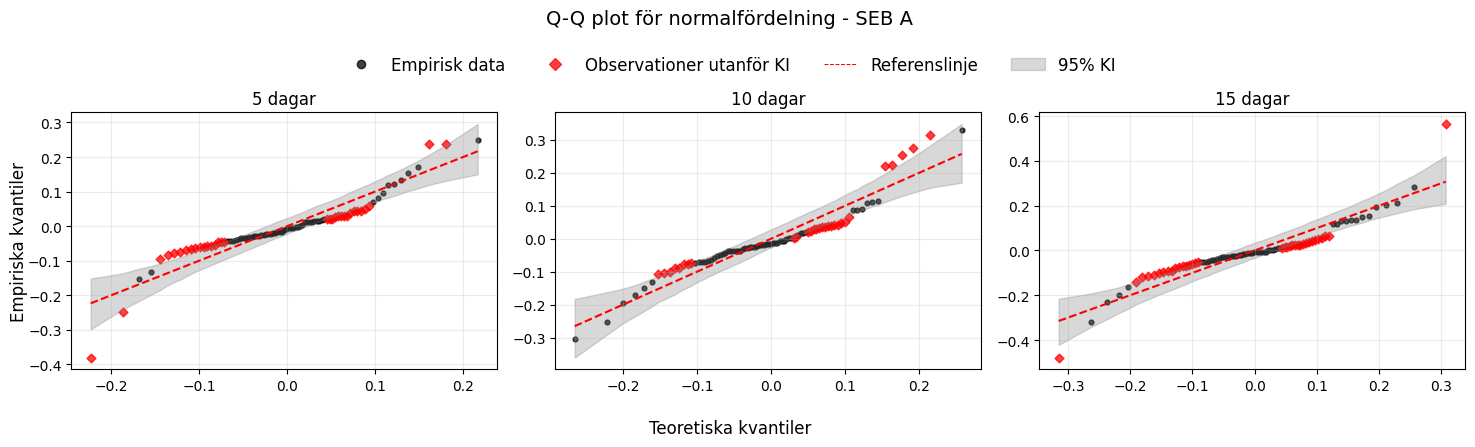

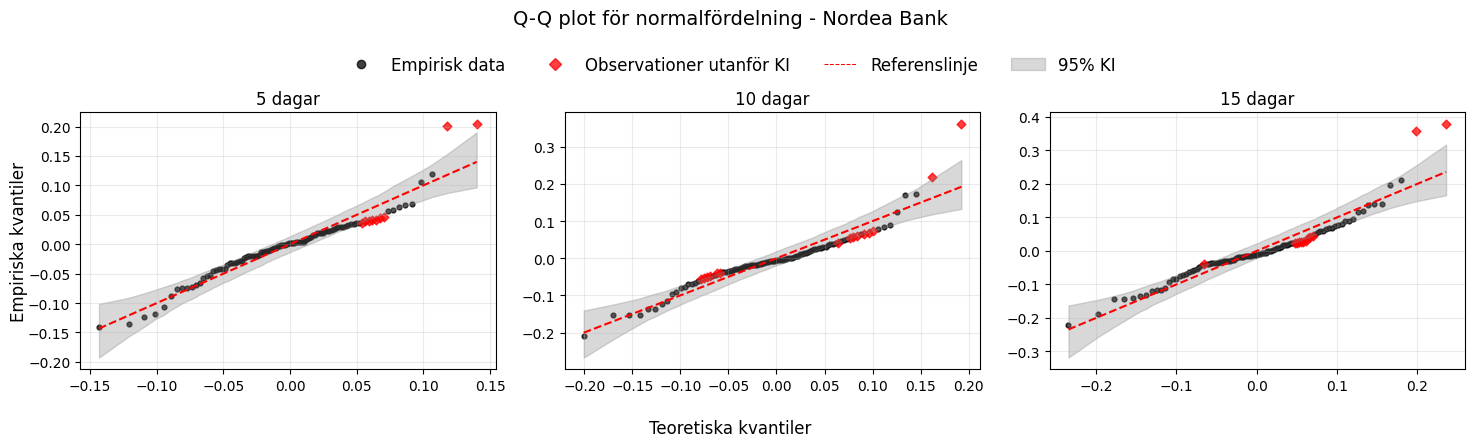

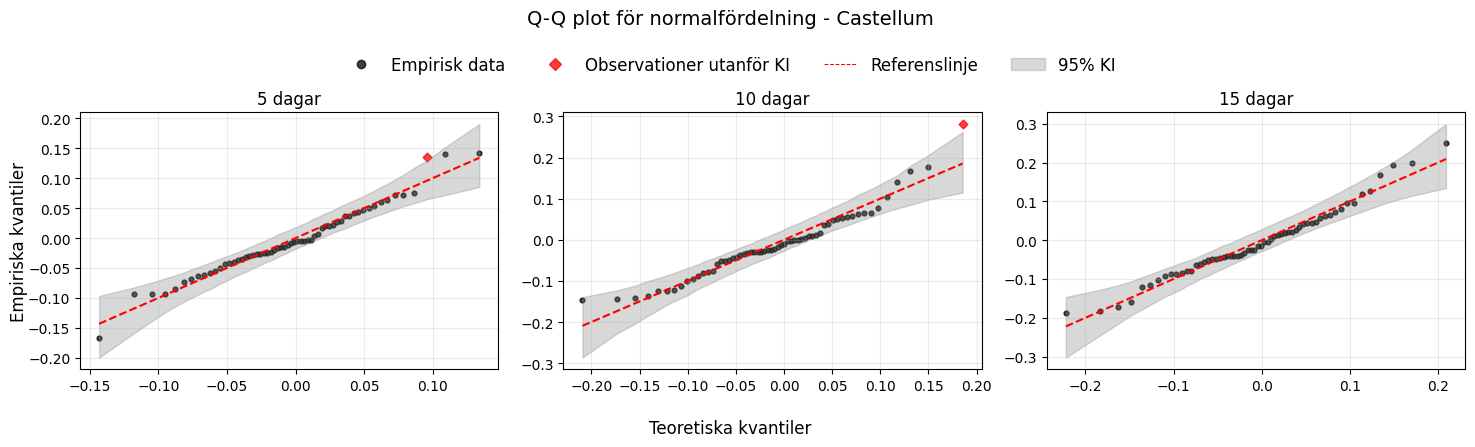

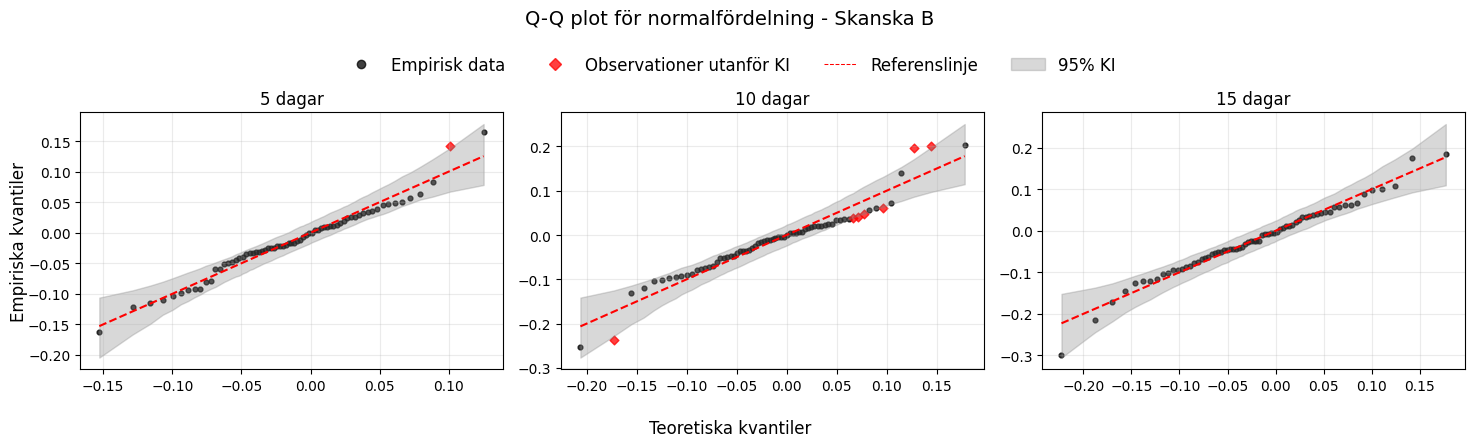

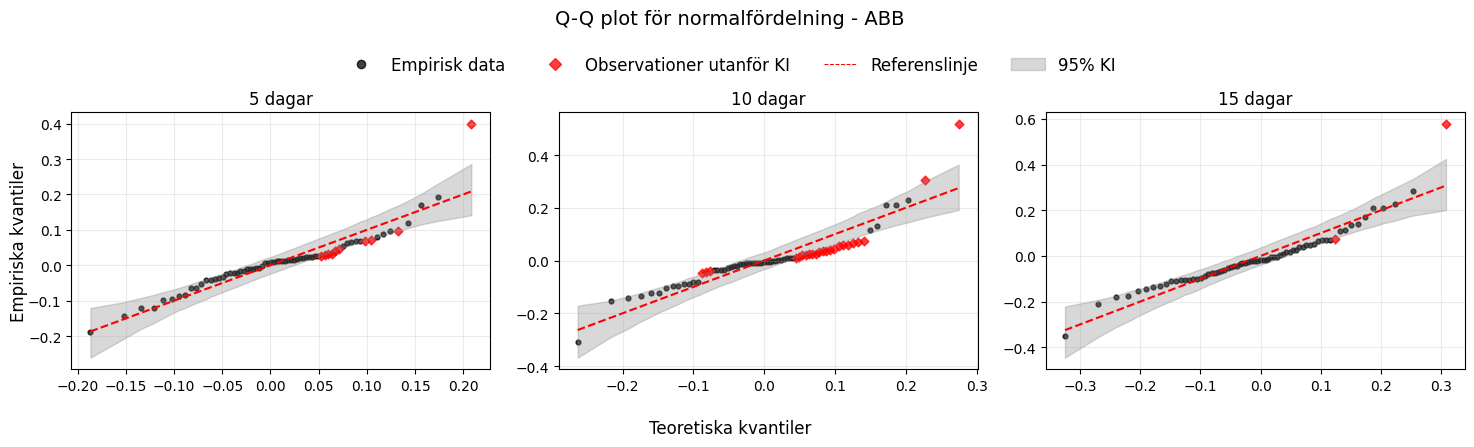

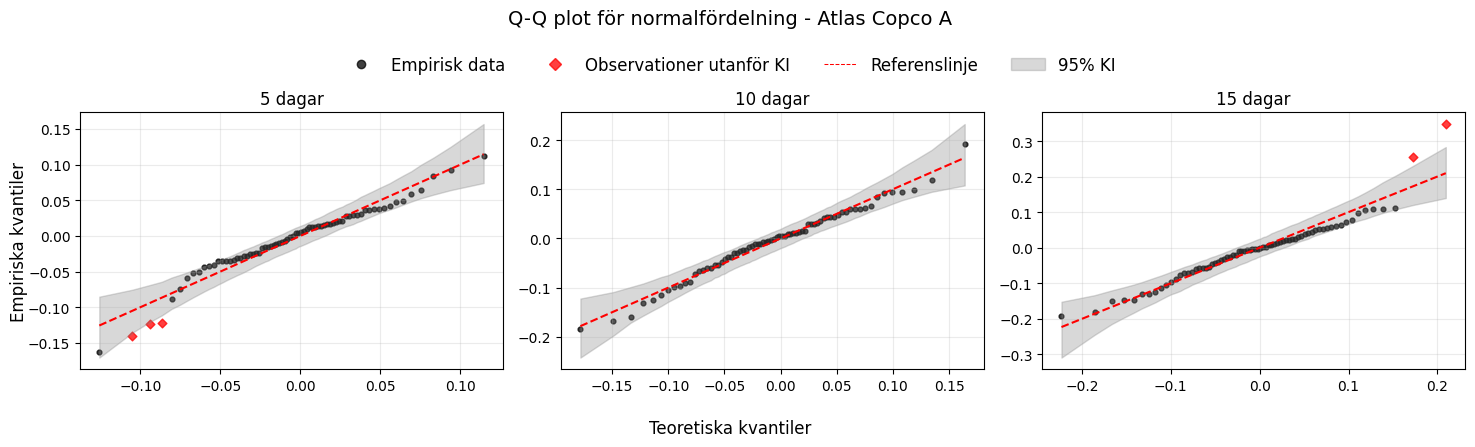

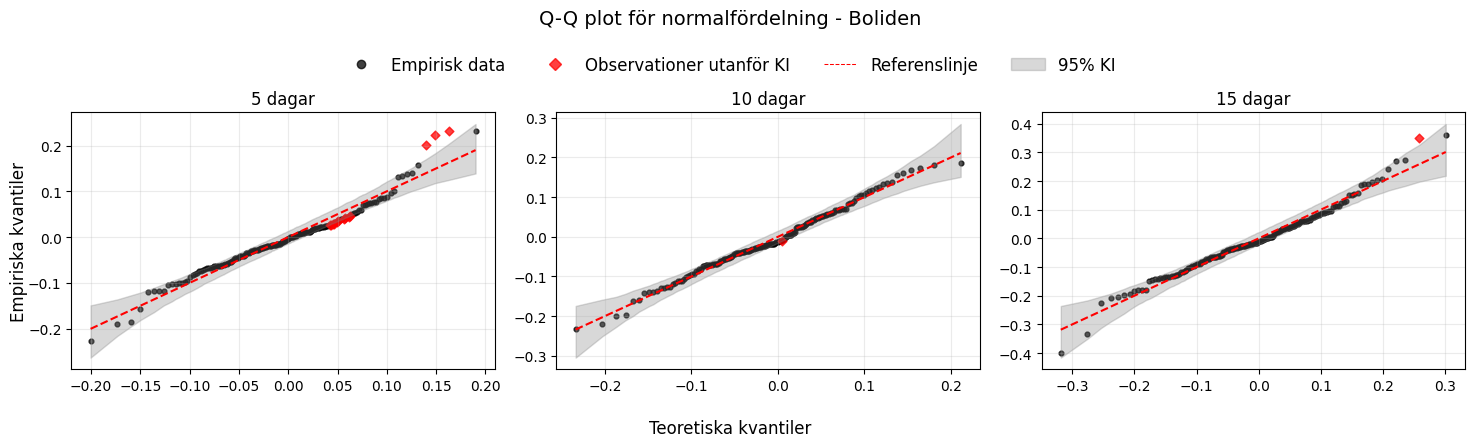

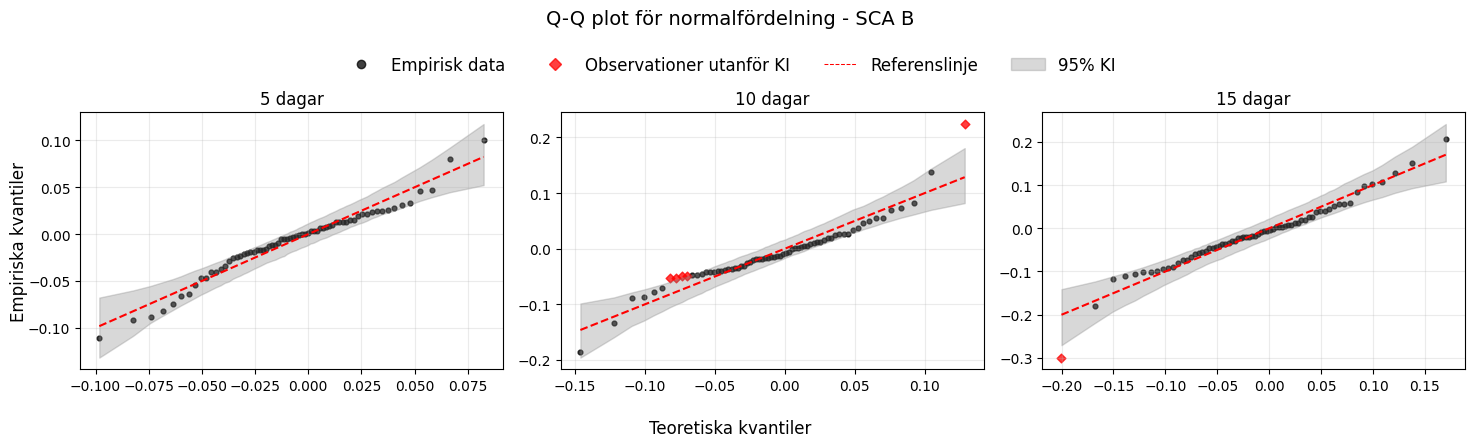

In [20]:
observation_window = 15          
recovery_horizons = [5, 10, 15] 

confidence = 0.95
n_boots = 2000
rng = np.random.default_rng(42)

for stock in loss_df.columns:

    ncols = 3
    nrows = 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    recovery_windows = evt.staticFiltering(u, loss_df, observation_window)

    for i, s in enumerate(recovery_horizons):
        ax = axes[i]

        ratios, recoveries,  no_recovery, recovery_50minus, recovery_50plus, full_recovery = evt.Generate_Recovery_Data(loss_df, recovery_windows,stock, window_size = s)
    
        col = f"{s} day recovery"
        data = recoveries[col].dropna()

        sorted_data = np.sort(data.to_numpy())
        n = len(sorted_data)

        p = (np.arange(1, n + 1) - 0.5) / n

        mu_hat, sigma_hat = sp.norm.fit(sorted_data)
        theoretical_q = sp.norm.ppf(p, loc=mu_hat, scale=sigma_hat)

        boot_samples = sp.norm.rvs(loc=mu_hat, scale=sigma_hat, size=(n_boots, n),random_state=rng)
        boot_samples_sort = np.sort(boot_samples, axis=1)

        lower_alpha = (1 - confidence) / 2
        upper_alpha = 1 - lower_alpha

        lower_band = np.percentile(boot_samples_sort, lower_alpha * 100, axis=0)
        upper_band = np.percentile(boot_samples_sort, upper_alpha * 100, axis=0)

        fitting_sorted_data = sorted_data[(sorted_data<upper_band) & (sorted_data>lower_band)]
        fitting_theoretical_q = theoretical_q[(sorted_data<upper_band) & (sorted_data>lower_band)]

        outside_sorted_data = sorted_data[(sorted_data>upper_band) | (sorted_data<lower_band)]
        outside_theoretical_q = theoretical_q[(sorted_data>upper_band) | (sorted_data<lower_band)]

        ax.scatter(fitting_theoretical_q,fitting_sorted_data, s=12, color="black", alpha=0.75)
        ax.scatter(outside_theoretical_q,outside_sorted_data, s=20, color="red", alpha=0.75, marker = "D")

        ax.plot(theoretical_q, theoretical_q, color="red", linestyle="--")
        ax.fill_between(theoretical_q, lower_band, upper_band, color="gray", alpha=0.3)

        ax.set_title(f"{s} dagar", fontsize=12)
     
        ax.grid(True, alpha = 0.25) 


    for j in range(len(recovery_horizons), len(axes)):
        fig.delaxes(axes[j])
    
    handles = [
        plt.Line2D([], [], marker='o', linestyle='None', color='black', alpha=0.75, label="Empirisk data"),
        plt.Line2D([], [], marker='D', linestyle='None', color='red', alpha=0.75, label="Observationer utanför KI"),
        plt.Line2D([], [], color="red", linestyle="--", label="Referenslinje", linewidth = 0.75),
        mpatches.Patch(color="gray", alpha=0.3, label=f"{int(confidence * 100)}% KI")
        ]

    fig.legend(handles=handles,loc='upper center', bbox_to_anchor=(0.5, 1.00), ncol=4,frameon=False, fontsize = 12)
    fig.suptitle(f"Q-Q plot för normalfördelning - {stock}", y=1.08, fontsize = 14)
    fig.supxlabel("Teoretiska kvantiler", fontsize=12)
    fig.supylabel("Empiriska kvantiler", fontsize=12)
    plt.tight_layout()
    plt.show()

### Visualisering av hur väl anpassade återhämtningarna är för t-distributionen

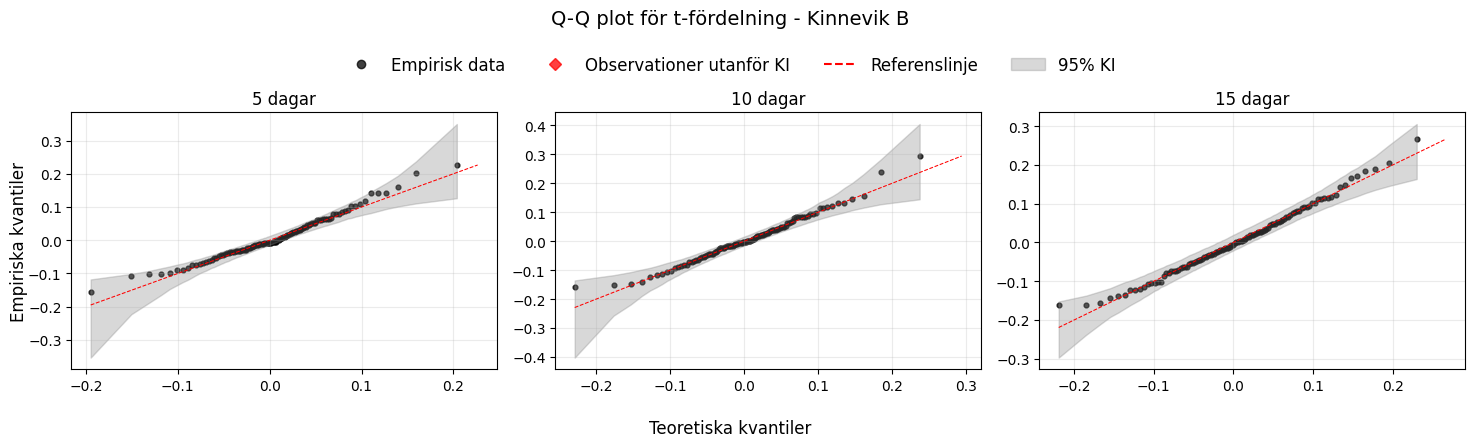

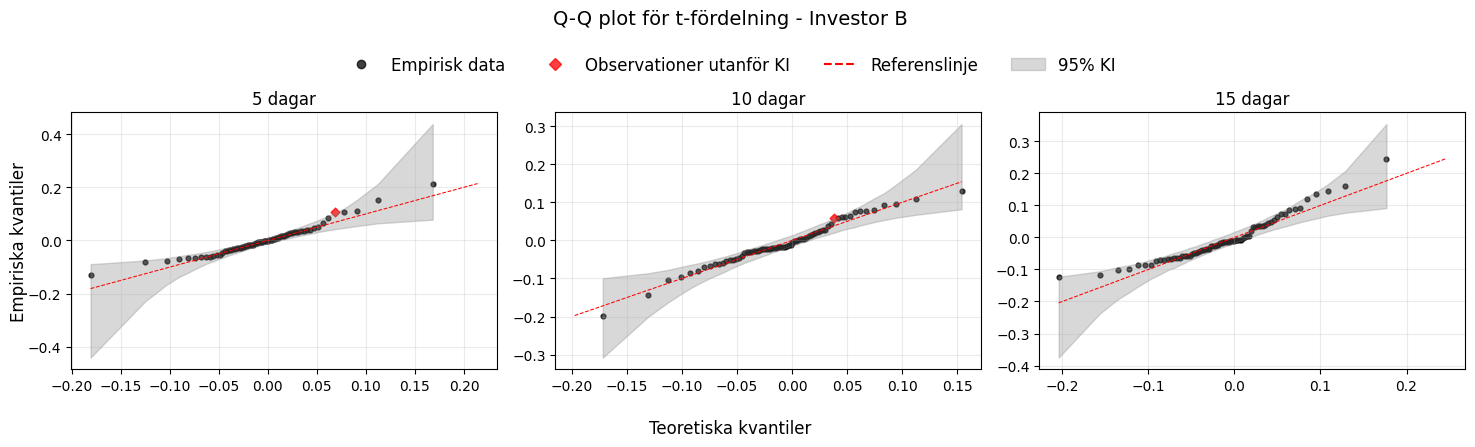

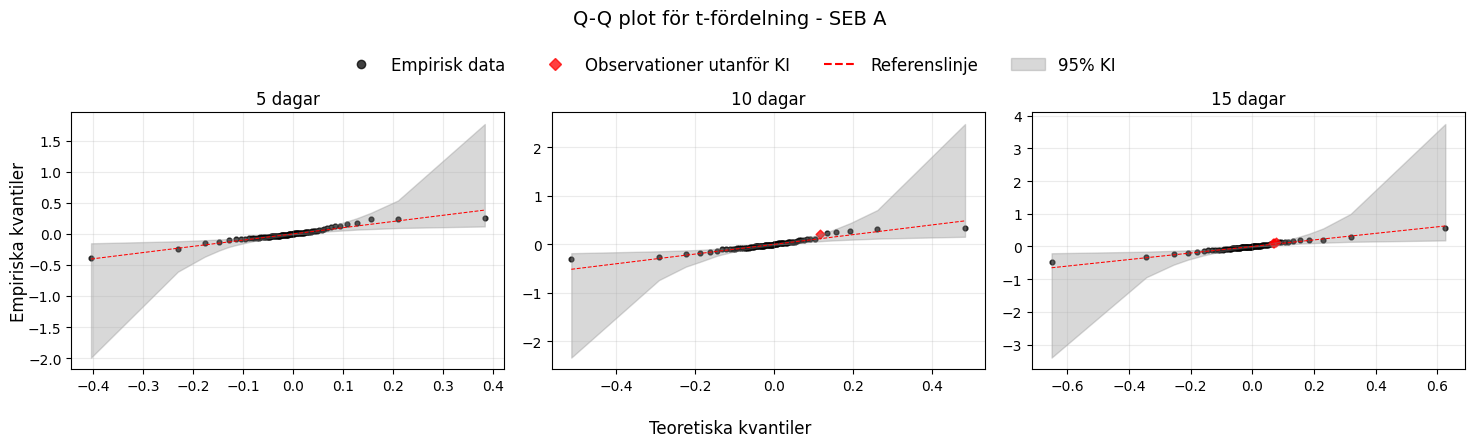

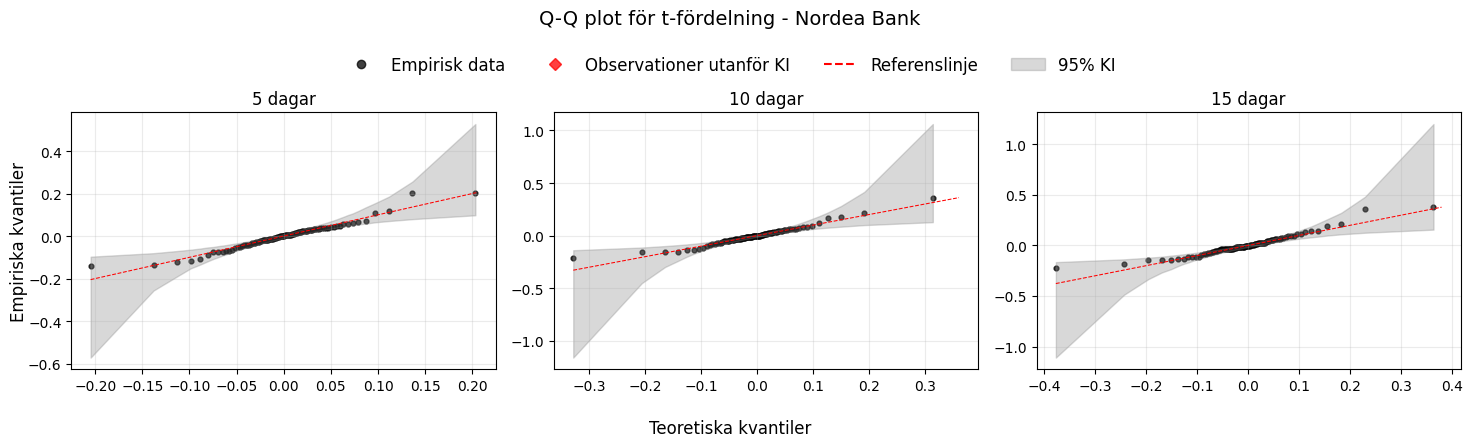

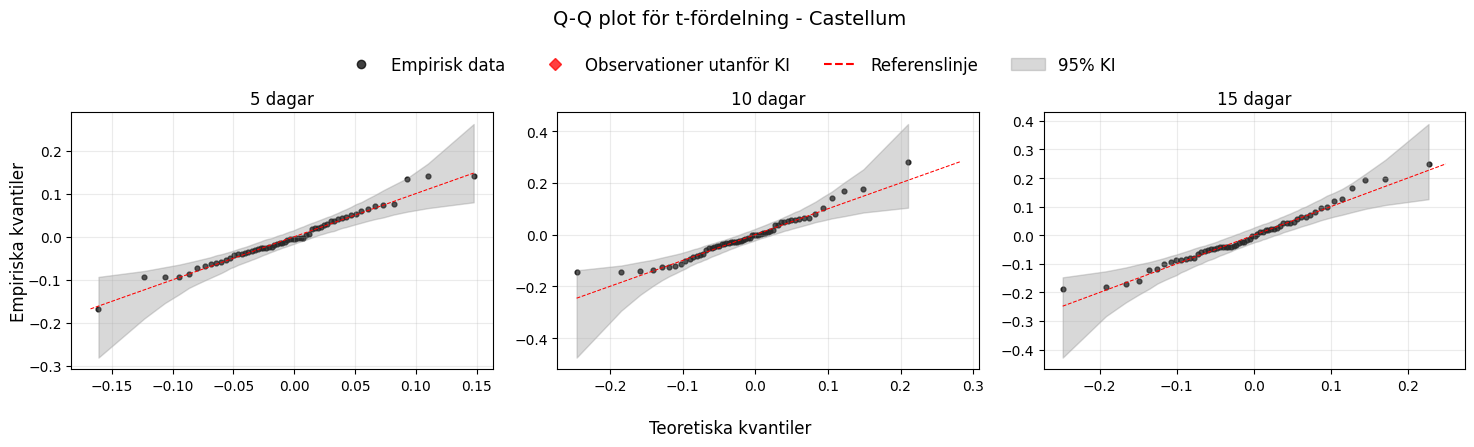

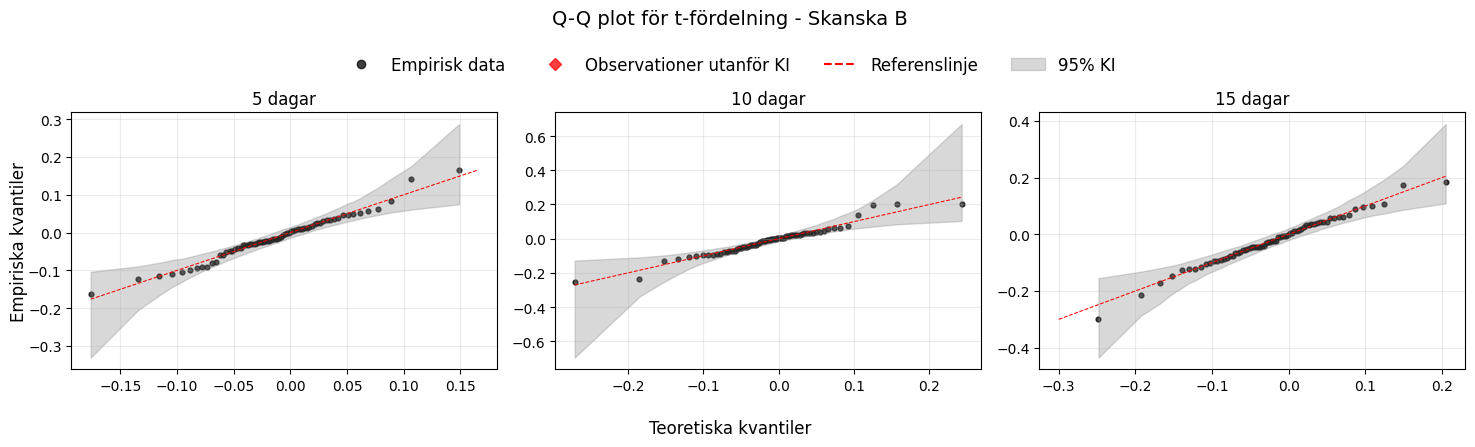

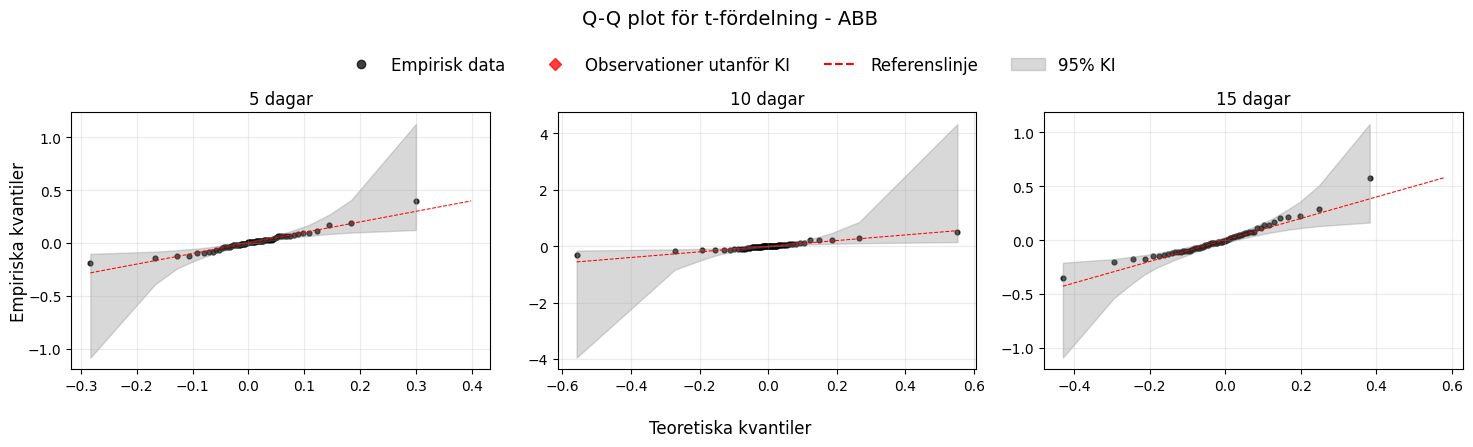

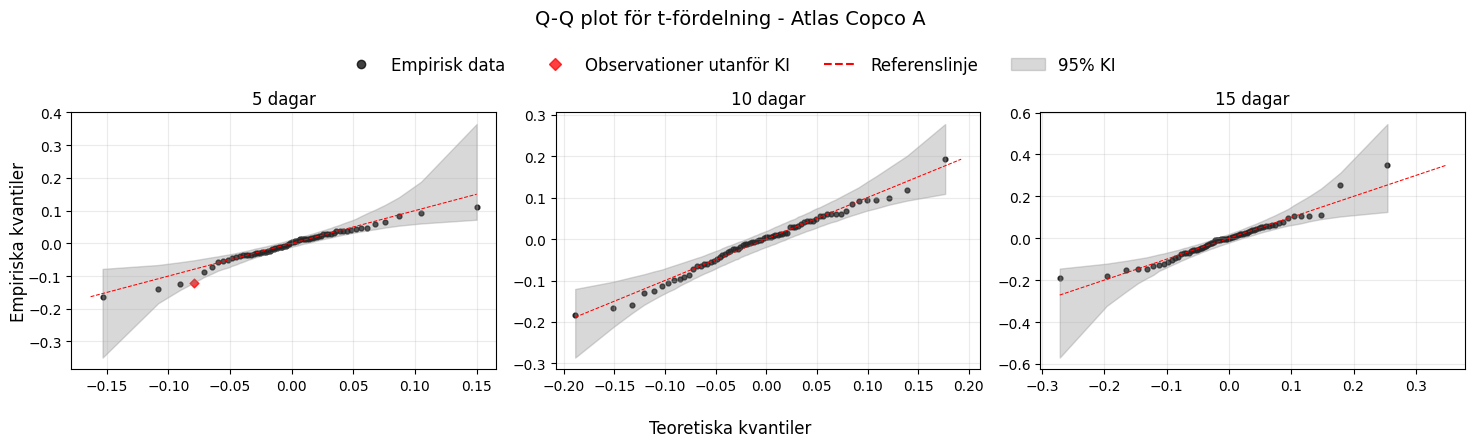

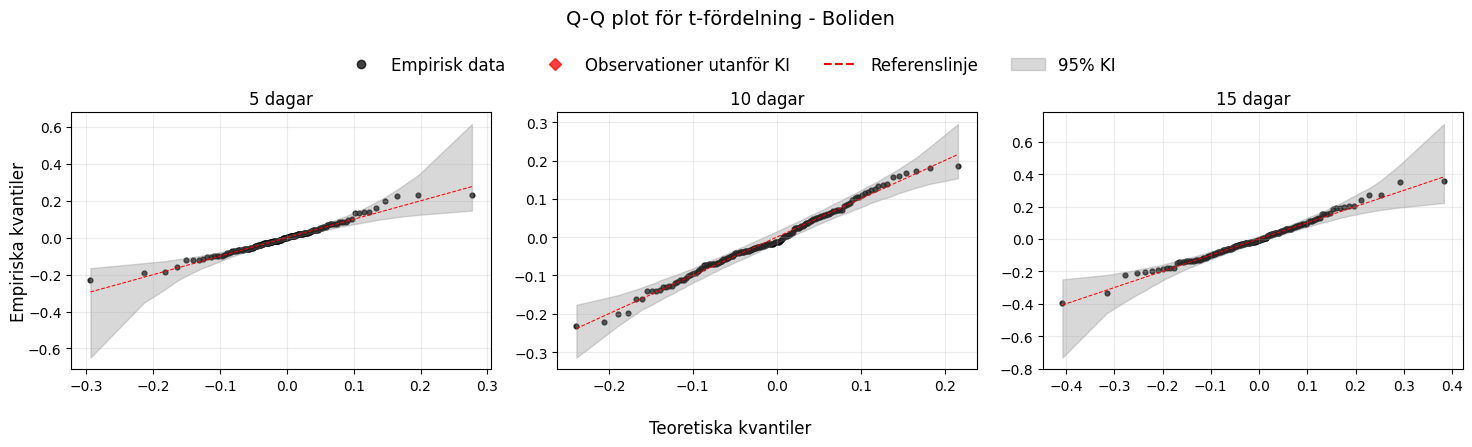

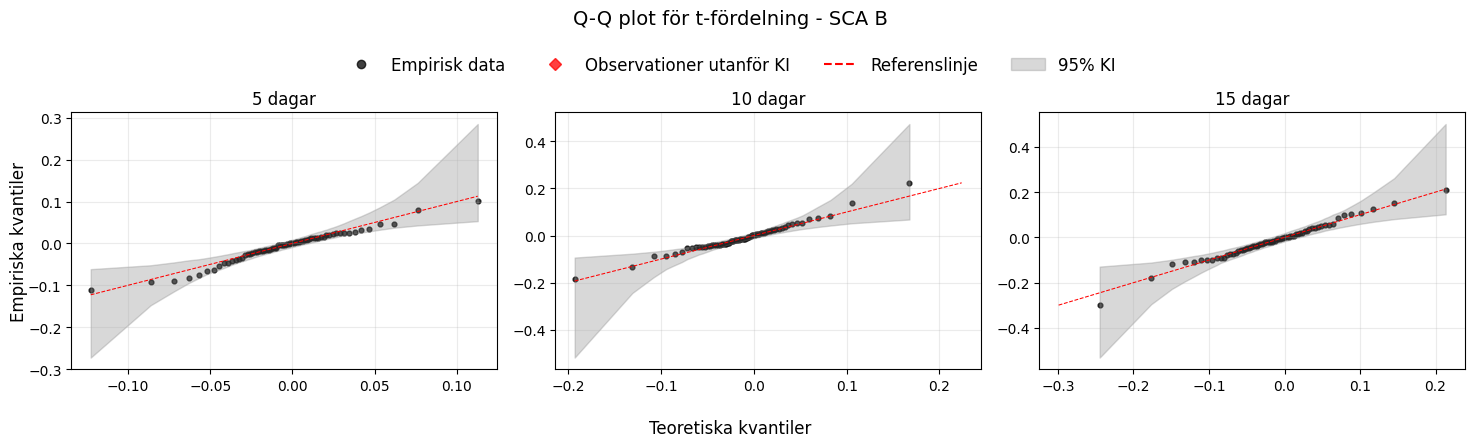

In [21]:
observation_window = 15        
recovery_horizons = [5, 10, 15]  

confidence = 0.95
n_boots = 2000
rng = np.random.default_rng(42)

for stock in loss_df.columns:

    ncols = 3
    nrows = 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    recovery_windows = evt.staticFiltering(u, loss_df, observation_window)

    for i, s in enumerate(recovery_horizons):
        ax = axes[i]

        ratios, recoveries, no_recovery, recovery_50minus, recovery_50plus, full_recovery = evt.Generate_Recovery_Data(loss_df, recovery_windows, stock, window_size = s)
        
        col = f"{s} day recovery"
        data = recoveries[col].dropna()

        sorted_data = np.sort(data.to_numpy())
        n = len(sorted_data)

        p = (np.arange(1, n + 1) - 0.5) / n

        df_hat, loc_hat, scale_hat = sp.t.fit(sorted_data)
        theoretical_q = sp.t.ppf(p, df_hat, loc_hat, scale_hat)

        boot_samples = sp.t.rvs(df=df_hat, loc=loc_hat, scale=scale_hat, size=(n_boots, n), random_state=rng)
        boot_samples_sort = np.sort(boot_samples, axis=1)

        lower_alpha = (1 - confidence) / 2
        upper_alpha = 1 - lower_alpha

        lower_band = np.percentile(boot_samples_sort, lower_alpha * 100, axis=0)
        upper_band = np.percentile(boot_samples_sort, upper_alpha * 100, axis=0)

        
        fitting_sorted_data = sorted_data[(sorted_data<upper_band) & (sorted_data>lower_band)]
        fitting_theoretical_q = theoretical_q[(sorted_data<upper_band) & (sorted_data>lower_band)]

        outside_sorted_data = sorted_data[(sorted_data>upper_band) | (sorted_data<lower_band)]
        outside_theoretical_q = theoretical_q[(sorted_data>upper_band) | (sorted_data<lower_band)]

        ax.scatter(fitting_theoretical_q,fitting_sorted_data, s=12, color="black", alpha=0.75)
        ax.scatter(outside_theoretical_q,outside_sorted_data, s=20, color="red", alpha=0.75, marker = "D")
        
        ax.fill_between(theoretical_q, lower_band, upper_band, color="gray", alpha=0.3)

        line_min = min(theoretical_q.min(), sorted_data.min())
        line_max = max(theoretical_q.max(), sorted_data.max())
        ax.plot([line_min, line_max], [line_min, line_max], "--", color="red", linewidth = 0.75)

        ax.set_title(f"{s} dagar", fontsize=12)
      
        ax.grid(True, alpha =0.25) 


    for j in range(len(recovery_horizons), len(axes)):
        fig.delaxes(axes[j])

    handles = [
        plt.Line2D([], [], marker='o', linestyle='None', color='black', alpha=0.75, label="Empirisk data"),
        plt.Line2D([], [], marker='D', linestyle='None', color='red', alpha=0.75, label="Observationer utanför KI"),
        plt.Line2D([], [], color="red", linestyle="--", label="Referenslinje"),
        mpatches.Patch(color="gray", alpha=0.3, label=f"{int(confidence * 100)}% KI")
        ]

    fig.legend(handles=handles,loc='upper center', bbox_to_anchor=(0.5, 1.00), ncol=4,frameon=False, fontsize = 12)
    fig.suptitle(f"Q-Q plot för t-fördelning - {stock}", y=1.08, fontsize = 14)
    fig.supxlabel("Teoretiska kvantiler", fontsize=12)
    fig.supylabel("Empiriska kvantiler", fontsize=12)
    

    plt.tight_layout()
    plt.show()

### Inhämtning av statistisk data

In [22]:
observation_window = 15         
recovery_horizons = [5, 10, 15]  
stat_results = []


for stock in loss_df.columns:
    sf = evt.staticFiltering(u, loss_df, observation_window)

    for s in recovery_horizons:
        ratios, recoveries,  no_recovery, recovery_50minus, recovery_50plus, full_recovery = evt.Generate_Recovery_Data(loss_df, sf, stock, window_size = s)

        col = f"{s} day recovery"
        data = recoveries[col]

        mu_hat, sigma_hat = sp.norm.fit(data)
        df, loc, scale = sp.t.fit(data)

        ks_norm = kstest(data, 'norm', args=(mu_hat, sigma_hat))
        ks_t = kstest(data, 't', args=(df, loc, scale))
        
        stat_results.append({"stock": stock, 
                             "days": s, 
                             "n": len(data), 
                             "zero_ratio": ratios[0], 
                             "ratio_50minus": ratios[1],
                             "ratio_50plus": ratios[2], 
                             "full_ratio": ratios[3], 
                             "df_t": df, 
                             "p_norm": ks_norm.pvalue, 
                             "p_t": ks_t.pvalue, 
                             "D_t": ks_t.statistic, 
                             "D_norm": ks_norm.statistic
                             })

stat_results_df = pd.DataFrame(stat_results)


In [23]:
# Tabell 1: Återhämtningsgrad 
tab_ratio = stat_results_df.pivot(index="stock", columns="days", values=["zero_ratio", "ratio_50minus", "ratio_50plus", "full_ratio"]).sort_index(axis=1)
tab_ratio = tab_ratio.round(3)
#display(tab_ratio)


# Tabell 2: Normalfördelning (KS-test)
tab_norm = stat_results_df.pivot(index="stock", columns="days", values=["D_norm", "p_norm"]).sort_index(axis=1)
tab_norm = tab_norm.round(3)
#display(tab_norm)

# Tabell 3: t-fördelning (KS-test + df)
tab_t = stat_results_df.pivot(index="stock", columns="days", values=["df_t", "D_t", "p_t"]).sort_index(axis=1)
tab_t = tab_t.round(3)
#display(tab_t)


In [24]:
mean_ratio = tab_ratio.mean(axis=0).unstack()
mean_ratio = mean_ratio.round(3)
print(mean_ratio)

days              5      10     15
full_ratio     0.137  0.222  0.280
ratio_50minus  0.238  0.205  0.167
ratio_50plus   0.169  0.155  0.141
zero_ratio     0.456  0.418  0.412


# Portfölj

In [25]:
weights = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])
Portfolio = evt.createPortfolio(shares=[loss_df[stock] for stock in loss_df.keys()], weights= weights)
threshold = np.quantile(a=Portfolio, q=0.975065)
portfolioThreshold = {
    "Portfolio" : threshold
}

s:  5
0:  0.43373493975903615
50-:  0.24096385542168675
50+:  0.13253012048192772
100:  0.1927710843373494
_________________________________
s:  10
0:  0.40963855421686746
50-:  0.0963855421686747
50+:  0.18072289156626506
100:  0.3132530120481928
_________________________________
s:  15
0:  0.40963855421686746
50-:  0.10843373493975904
50+:  0.14457831325301204
100:  0.3373493975903614
_________________________________


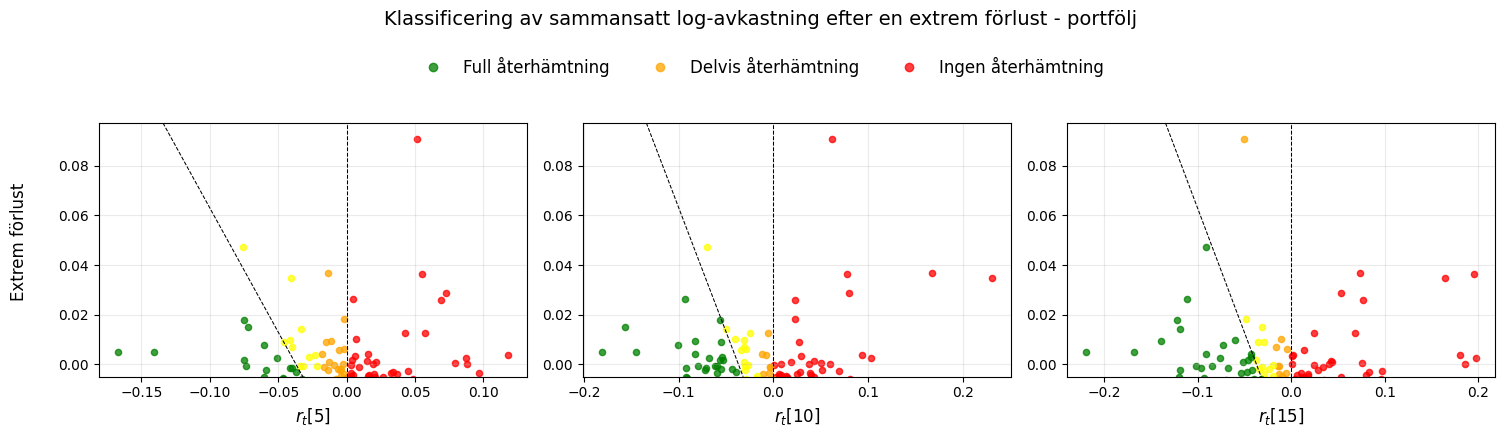

In [26]:
portfolio = "Portfolio"
ncols = min(3, len(recovery_horizons))
nrows = int(np.ceil(len(recovery_horizons) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).ravel()
recovery_windows = evt.staticFiltering(portfolioThreshold, Portfolio, observation_window)
    
for i, s in enumerate(recovery_horizons):
    ax = axes[i]

    
    ratio,recoveries,no_recovery,recovery_50minus,recovery_50plus,full_recovery = evt.Generate_Recovery_Data(Portfolio, recovery_windows,portfolio, window_size = s)
    print("s: ", s)
    print("0: ", ratio[0])
    print("50-: ", ratio[1])
    print("50+: ", ratio[2])
    print("100: ", ratio[3])
    print("_________________________________")
    col = f"{s} day recovery"

    ax.scatter(no_recovery[col], no_recovery["Loss"]-u[stock], s=20, alpha=0.75, color="red")
    ax.scatter(recovery_50minus[col], recovery_50minus["Loss"]-u[stock], s=20, alpha=0.75, color="orange")
    ax.scatter(recovery_50plus[col], recovery_50plus["Loss"]-u[stock], s=20, alpha=0.75, color="yellow")
    
    ax.scatter(full_recovery[col], full_recovery["Loss"]-u[stock], s=20, alpha=0.75, color="green")

    ax.axline((0, -u[stock]), slope=-1, color="black", linestyle = "dashed", linewidth = 0.75)
    ax.axvline(x=0, color="black", linestyle="dashed", linewidth = 0.75)
        
    ax.grid(True, alpha =0.25) 
    ax.set_ylim(bottom=-0.005)
    ax.set_xlabel(rf"$r_t[{s}]$", fontsize=12) 
for j in range(len(recovery_horizons), len(axes)):
    fig.delaxes(axes[j])
    
handles = [
    plt.Line2D([], [], marker='o', linestyle='', alpha = 0.75, color='green', label='Full återhämtning'),
    plt.Line2D([], [], marker='o', linestyle='', alpha = 0.75, color='orange', label='Delvis återhämtning'),
    plt.Line2D([], [], marker='o', linestyle='', alpha = 0.75, color='red', label='Ingen återhämtning')
    ]
    
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1), ncol=4, frameon= False, fontsize = 12)
fig.supylabel("Extrem förlust", fontsize = 12,x=-0.0001)
fig.suptitle(rf"Klassificering av sammansatt log-avkastning efter en extrem förlust - portfölj", y=1.08, fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

s:  5 , statistic:  0.08476715965706749 , p-value:  0.560846479492041
s:  10 , statistic:  0.05921285229637363 , p-value:  0.9162667850474303
s:  15 , statistic:  0.07901691566342894 , p-value:  0.6486206317297376


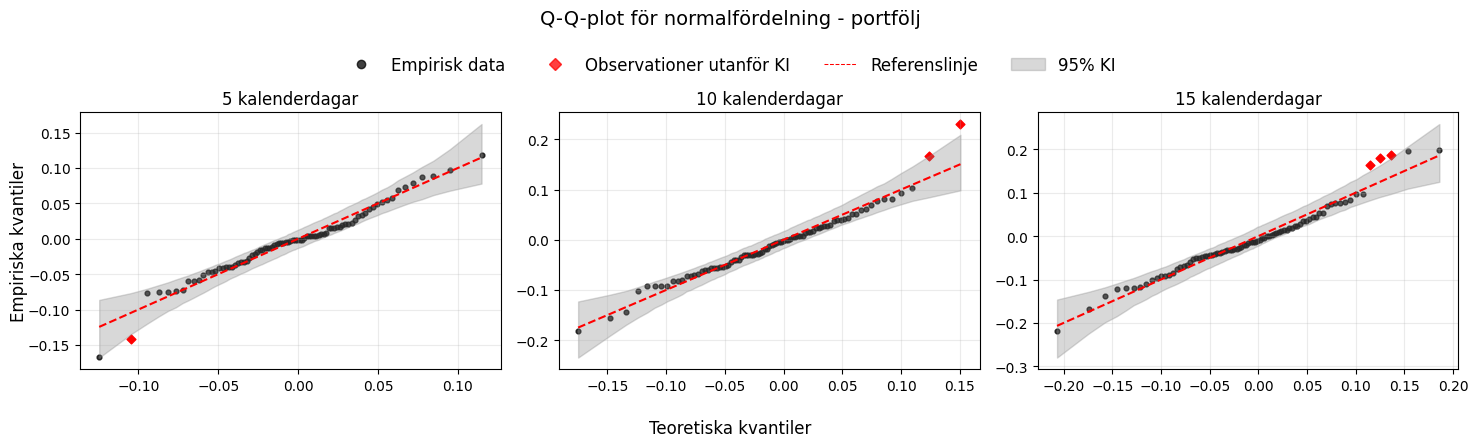

In [27]:
confidence = 0.95
n_boots = 2000
rng = np.random.default_rng(42)

N = [0] * len(recovery_horizons)
mean = [0] * len(recovery_horizons)
sd = [0] * len(recovery_horizons)
ratios = [0] * len(recovery_horizons)
ncols = 3
nrows = 1

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).ravel()

recovery_windows = evt.staticFiltering(portfolioThreshold, Portfolio, observation_window)
    

for i, s in enumerate(recovery_horizons):
    ax = axes[i]
    
    ratio,recoveries,no_recovery,recovery_50minus,recovery_50plus,full_recovery = evt.Generate_Recovery_Data(Portfolio, recovery_windows,portfolio, window_size = s)
    

    col = f"{s} day recovery"
    data = recoveries[col].dropna()

    mu_hat, sigma_hat = sp.norm.fit(data)
    
    ks_norm = kstest(data, 'norm', args=(mu_hat, sigma_hat))
    
    print("s: ",s, ", statistic: ",ks_norm.statistic, ", p-value: ",ks_norm.pvalue)

   
    sorted_data = np.sort(data.to_numpy())
    n = len(sorted_data)

    p = (np.arange(1, n + 1) - 0.5) / n

    mu_hat, sigma_hat = sp.norm.fit(sorted_data)
    theoretical_q = sp.norm.ppf(p, loc=mu_hat, scale=sigma_hat)

    

    boot_samples = sp.norm.rvs(loc=mu_hat, scale=sigma_hat, size=(n_boots, n),random_state=rng)
    boot_samples_sort = np.sort(boot_samples, axis=1)

    lower_alpha = (1 - confidence) / 2
    upper_alpha = 1 - lower_alpha

    lower_band = np.percentile(boot_samples_sort, lower_alpha * 100, axis=0)
    upper_band = np.percentile(boot_samples_sort, upper_alpha * 100, axis=0)

    fitting_sorted_data = sorted_data[(sorted_data < upper_band) & (sorted_data > lower_band)]
    fitting_theoretical_q = theoretical_q[(sorted_data < upper_band) & (sorted_data > lower_band)]

    outside_sorted_data = sorted_data[(sorted_data > upper_band) | (sorted_data < lower_band)]
    outside_theoretical_q = theoretical_q[(sorted_data > upper_band) | (sorted_data < lower_band)]


    ax.scatter(fitting_theoretical_q, fitting_sorted_data, s=12, color="black", alpha=0.75)
    ax.scatter(outside_theoretical_q, outside_sorted_data, s=20, color="red", alpha=1, marker= "D")
    ax.plot(theoretical_q, theoretical_q, color="red", linestyle="--")
    ax.fill_between(theoretical_q, lower_band, upper_band, color="gray", alpha=0.3)
    
    ax.set_title(f"{s} kalenderdagar", fontsize=12)
     
    ax.grid(True, alpha = 0.25) 
    

for j in range(len(recovery_horizons), len(axes)):
    fig.delaxes(axes[j])
    
handles = [
    plt.Line2D([], [], marker='o', linestyle='None', color='black', alpha=0.75, label="Empirisk data"),
    plt.Line2D([], [], marker='D', linestyle='None', color='red', alpha=0.75, label="Observationer utanför KI"),
    plt.Line2D([], [], color="red", linestyle="--", label="Referenslinje", linewidth = 0.75),
    mpatches.Patch(color="gray", alpha=0.3, label=f"{int(confidence * 100)}% KI")
    ]

fig.legend(handles=handles,loc='upper center', bbox_to_anchor=(0.5, 1.00), ncol=4,frameon=False, fontsize = 12)
fig.suptitle(f"Q-Q-plot för normalfördelning - portfölj", y=1.08, fontsize = 14)
fig.supxlabel("Teoretiska kvantiler", fontsize=12)
fig.supylabel("Empiriska kvantiler", fontsize=12)
plt.tight_layout()
plt.show()


5 ,df:  4.594938513435917 ,statistic:  0.056520540821098586 , pvalue:  0.9399268701463928
10 ,df:  5.597300233799236 ,statistic:  0.04724149250771009 , pvalue:  0.9883431241256055
15 ,df:  4.567193688309473 ,statistic:  0.05179879619322533 , pvalue:  0.9707628414588706


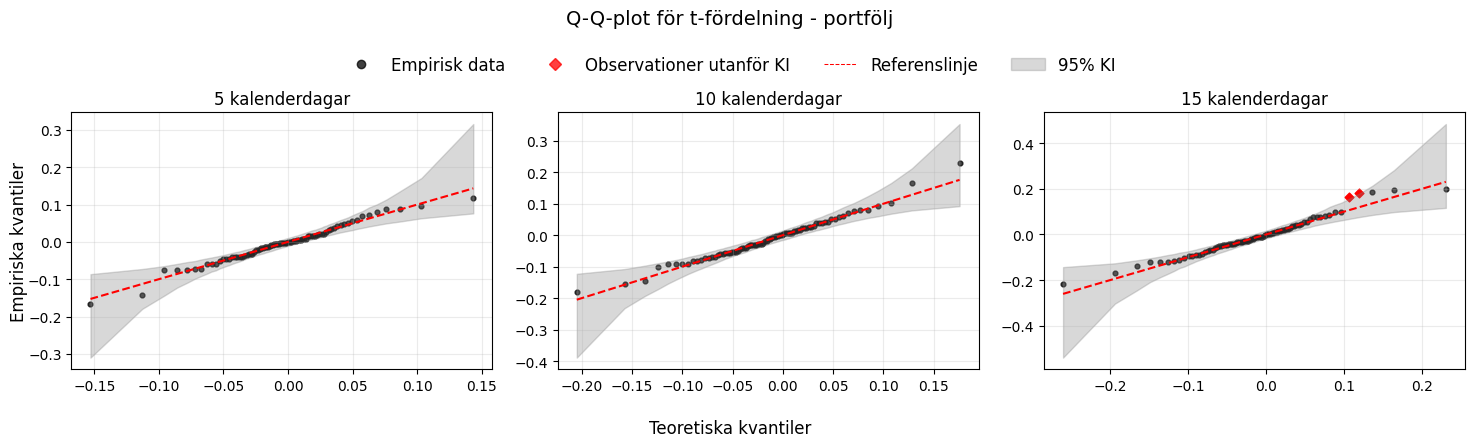

In [28]:
confidence = 0.95
n_boots = 2000
rng = np.random.default_rng(42)

N = [0] * len(recovery_horizons)
mean = [0] * len(recovery_horizons)
sd = [0] * len(recovery_horizons)
ratios = [0] * len(recovery_horizons)

ncols = min(3, len(recovery_horizons))
nrows = int(np.ceil(len(recovery_horizons) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).ravel()

recovery_windows = evt.staticFiltering(portfolioThreshold, Portfolio, observation_window)


for i, s in enumerate(recovery_horizons):
    ax = axes[i]

    
    ratio,recoveries,no_recovery,recovery_50minus,recovery_50plus,full_recovery = evt.Generate_Recovery_Data(Portfolio, recovery_windows,portfolio, window_size = s)
    
    col = f"{s} day recovery"
    data = recoveries[col].dropna()

    df, loc, scale = sp.t.fit(data)

    ks_t = kstest(data, 't', args=(df, loc, scale))
    print(s, ",df: ", df,  ",statistic: " , ks_t.statistic, ", pvalue: ",ks_t.pvalue,)    

    
    sorted_data = np.sort(data.to_numpy())
    n = len(sorted_data)

    p = (np.arange(1, n + 1) - 0.5) / n

    df_hat, loc_hat, scale_hat = sp.t.fit(sorted_data)
    theoretical_q = sp.t.ppf(p, df_hat, loc_hat, scale_hat)

    boot_samples = sp.t.rvs(df=df_hat, loc=loc_hat, scale=scale_hat, size=(n_boots, n), random_state=rng)
    boot_samples_sort = np.sort(boot_samples, axis=1)

    lower_alpha = (1 - confidence) / 2
    upper_alpha = 1 - lower_alpha

    lower_band = np.percentile(boot_samples_sort, lower_alpha * 100, axis=0)
    upper_band = np.percentile(boot_samples_sort, upper_alpha * 100, axis=0)

    fitting_sorted_data = sorted_data[(sorted_data < upper_band) & (sorted_data > lower_band)]
    fitting_theoretical_q = theoretical_q[(sorted_data < upper_band) & (sorted_data > lower_band)]

    outside_sorted_data = sorted_data[(sorted_data > upper_band) | (sorted_data < lower_band)]
    outside_theoretical_q = theoretical_q[(sorted_data > upper_band) | (sorted_data < lower_band)]


    ax.scatter(fitting_theoretical_q, fitting_sorted_data, s=12, color="black", alpha=0.75)
    ax.scatter(outside_theoretical_q, outside_sorted_data, s=20, color="red", alpha=1, marker= "D")
    ax.plot(theoretical_q, theoretical_q, color="red", linestyle="--")
    ax.fill_between(theoretical_q, lower_band, upper_band, color="gray", alpha=0.3)
    
    ax.set_title(f"{s} kalenderdagar", fontsize=12)
     
    ax.grid(True, alpha = 0.25) 


for j in range(len(recovery_horizons), len(axes)):
    fig.delaxes(axes[j])
    
handles = [
    plt.Line2D([], [], marker='o', linestyle='None', color='black', alpha=0.75, label="Empirisk data"),
    plt.Line2D([], [], marker='D', linestyle='None', color='red', alpha=0.75, label="Observationer utanför KI"),
    plt.Line2D([], [], color="red", linestyle="--", label="Referenslinje", linewidth = 0.75),
    mpatches.Patch(color="gray", alpha=0.3, label=f"{int(confidence * 100)}% KI")
    ]

fig.legend(handles=handles,loc='upper center', bbox_to_anchor=(0.5, 1.00), ncol=4,frameon=False, fontsize = 12)
fig.suptitle(f"Q-Q-plot för t-fördelning - portfölj", y=1.08, fontsize = 14)
fig.supxlabel("Teoretiska kvantiler", fontsize=12)
fig.supylabel("Empiriska kvantiler", fontsize=12)
    

plt.tight_layout()
plt.show()